# Notebook 03 — Exploratory Data Analysis (EDA)
## Machine Learning-based Late Delivery Risk Prediction in Global Supply Chain Operations
**Client:** APL Logistics (KWE Group) | **Platform:** Unified Mentor

### Objective
This notebook explores the cleaned dataset through visualizations to understand patterns, distributions, and key drivers of late delivery risk. All figures are saved to reports/eda_figures/.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Color palette
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

# Figure save path
FIG_PATH = '../reports/eda_figures/'
os.makedirs(FIG_PATH, exist_ok=True)

print(f"Figures will be saved to: {FIG_PATH}")

Figures will be saved to: ../reports/eda_figures/


In [2]:
#Loading cleaned datasets

data = pd.read_csv('../data/cleaned_data.csv')

df = data.copy()
print(f"Cleaned Dataset Shape: {df.shape}")
df.head()

Cleaned Dataset Shape: (180517, 28)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Market,Order City,Order Country,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,1,Cardio Equipment,Brownsville,EE. UU.,Consumer,TX,Footwear,Pacific Asia,Mumbai,India,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,0,Shop By Sport,Littleton,EE. UU.,Consumer,CO,Golf,LATAM,San Pedro Sula,Honduras,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,Cortés,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,0,Water Sports,Littleton,EE. UU.,Consumer,CO,Fan Shop,LATAM,San Pedro Sula,Honduras,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,Cortés,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,1,Water Sports,Littleton,EE. UU.,Consumer,CO,Fan Shop,USCA,New York City,Estados Unidos,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,1,Women's Apparel,Littleton,EE. UU.,Consumer,CO,Golf,USCA,New York City,Estados Unidos,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


## 1. Target Variable Distribution

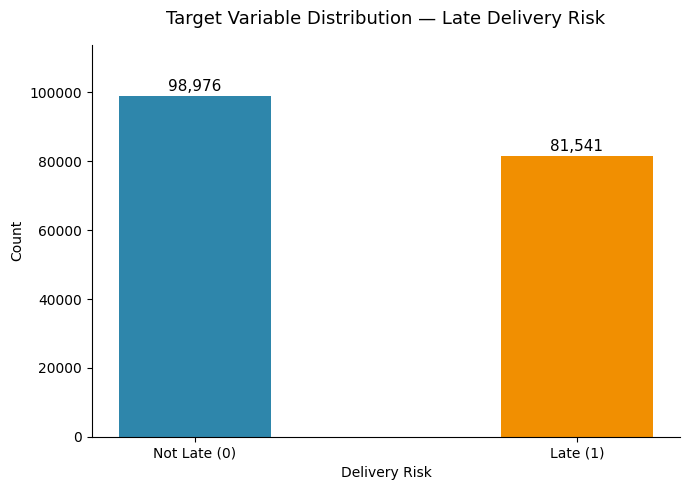

Saved: 01_target_distribution.png


In [3]:
target_counts = df['Late_delivery_risk'].value_counts()
labels = ['Not Late (0)', 'Late (1)']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, target_counts.values, color=[COLORS[0], COLORS[2]], width=0.4)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{bar.get_height():,}',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Target Variable Distribution — Late Delivery Risk', fontsize=13, pad=15)
ax.set_ylabel('Count')
ax.set_xlabel('Delivery Risk')
ax.set_ylim(0, max(target_counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_target_distribution.png")

## 2. Shipping Mode Distribution

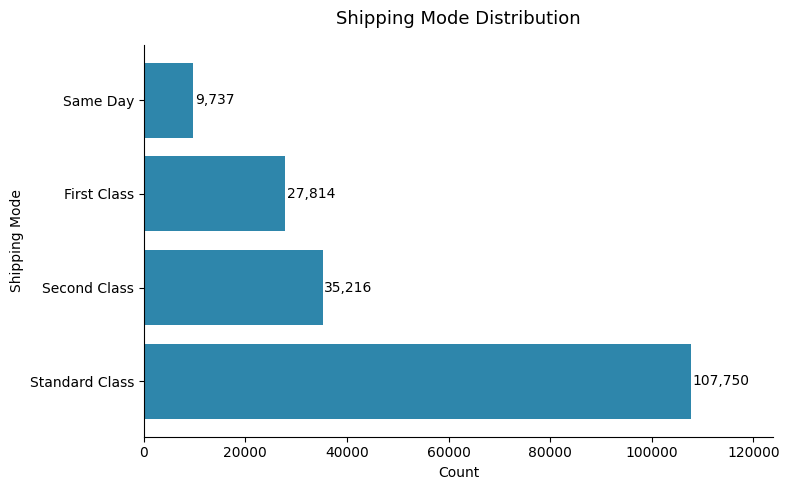

Saved: 02_shipping_mode_distribution.png


In [4]:
shipping_counts = df['Shipping Mode'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(shipping_counts.index, shipping_counts.values, color=COLORS[0])

for bar in bars:
    ax.text(bar.get_width() + 300,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():,}',
            va='center', fontsize=10)

ax.set_title('Shipping Mode Distribution', fontsize=13, pad=15)
ax.set_xlabel('Count')
ax.set_ylabel('Shipping Mode')
ax.set_xlim(0, max(shipping_counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '02_shipping_mode_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_shipping_mode_distribution.png")

## 3. Late Delivery Rate by Key Categories

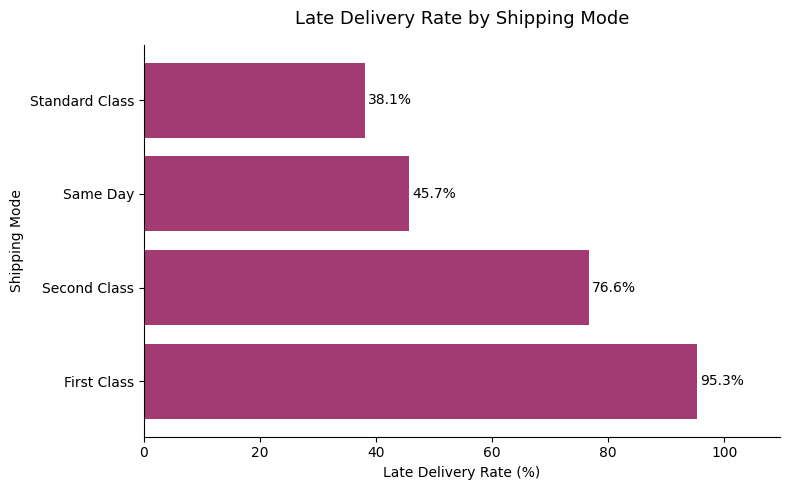

Saved: 03_late_rate_by_shipping_mode.png


In [6]:
#Late Delivery Rate by Shipping Mode

shipping_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
shipping_risk = shipping_risk.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(shipping_risk.index, shipping_risk.values, color=COLORS[1])

for bar in bars:
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=10)

ax.set_title('Late Delivery Rate by Shipping Mode', fontsize=13, pad=15)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('Shipping Mode')
ax.set_xlim(0, max(shipping_risk.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '03_late_rate_by_shipping_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_late_rate_by_shipping_mode.png")

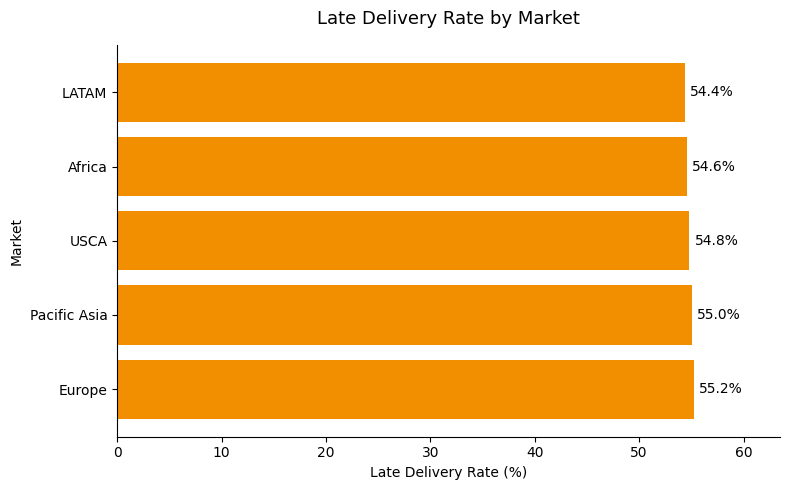

Saved: 04_late_rate_by_market.png


In [8]:
# Late Delivery Rate by Market

market_risk = df.groupby('Market')['Late_delivery_risk'].mean() * 100
market_risk = market_risk.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(market_risk.index, market_risk.values, color=COLORS[2])

for bar in bars:
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=10)

ax.set_title('Late Delivery Rate by Market', fontsize=13, pad=15)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('Market')
ax.set_xlim(0, max(market_risk.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '04_late_rate_by_market.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_late_rate_by_market.png")

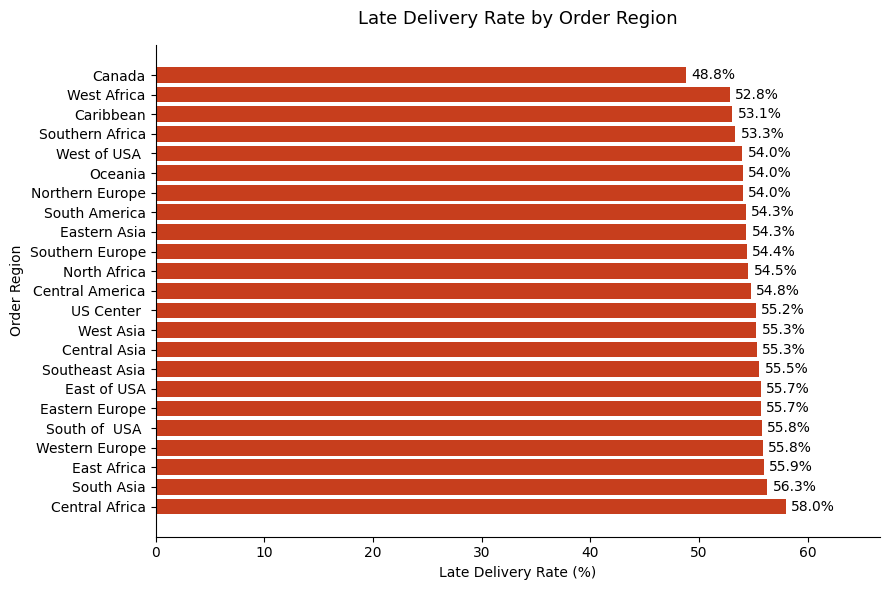

Saved: 05_late_rate_by_region.png


In [9]:
# Late Delivery Rate by Order Region

region_risk = df.groupby('Order Region')['Late_delivery_risk'].mean() * 100
region_risk = region_risk.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(region_risk.index, region_risk.values, color=COLORS[3])

for bar in bars:
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=10)

ax.set_title('Late Delivery Rate by Order Region', fontsize=13, pad=15)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('Order Region')
ax.set_xlim(0, max(region_risk.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '05_late_rate_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_late_rate_by_region.png")

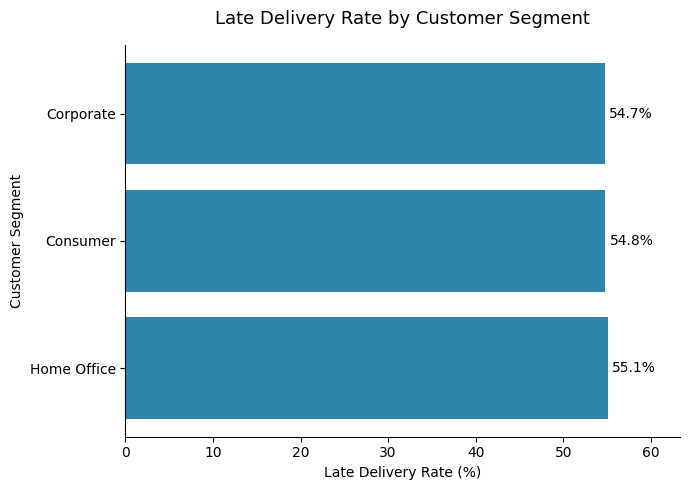

Saved: 06_late_rate_by_segment.png


In [10]:
#Late Delivery Rate by Customer Segment

segment_risk = df.groupby('Customer Segment')['Late_delivery_risk'].mean() * 100
segment_risk = segment_risk.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(segment_risk.index, segment_risk.values, color=COLORS[0])

for bar in bars:
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=10)

ax.set_title('Late Delivery Rate by Customer Segment', fontsize=13, pad=15)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('Customer Segment')
ax.set_xlim(0, max(segment_risk.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '06_late_rate_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_late_rate_by_segment.png")

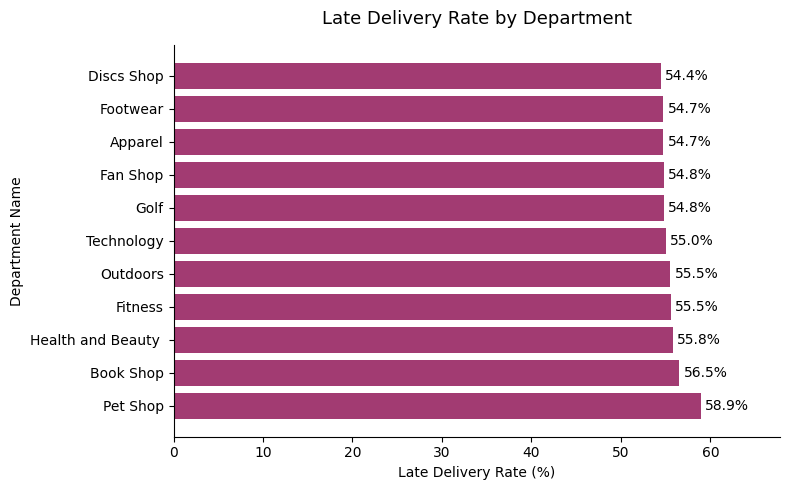

Saved: 07_late_rate_by_department.png


In [11]:
# Late Delivery Rate by Department

dept_risk = df.groupby('Department Name')['Late_delivery_risk'].mean() * 100
dept_risk = dept_risk.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(dept_risk.index, dept_risk.values, color=COLORS[1])

for bar in bars:
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=10)

ax.set_title('Late Delivery Rate by Department', fontsize=13, pad=15)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('Department Name')
ax.set_xlim(0, max(dept_risk.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '07_late_rate_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_late_rate_by_department.png")

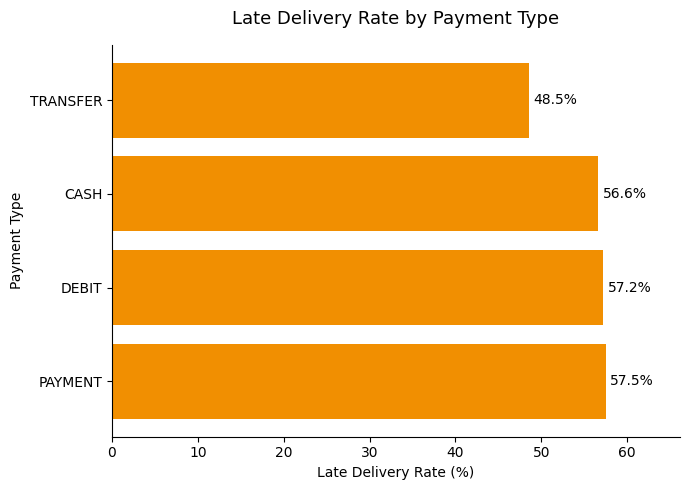

Saved: 08_late_rate_by_payment_type.png


In [12]:
# Late Delivery Rate by Payment Type

type_risk = df.groupby('Type')['Late_delivery_risk'].mean() * 100
type_risk = type_risk.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(type_risk.index, type_risk.values, color=COLORS[2])

for bar in bars:
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=10)

ax.set_title('Late Delivery Rate by Payment Type', fontsize=13, pad=15)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('Payment Type')
ax.set_xlim(0, max(type_risk.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '08_late_rate_by_payment_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_late_rate_by_payment_type.png")

## 4. Shipping Day Analysis

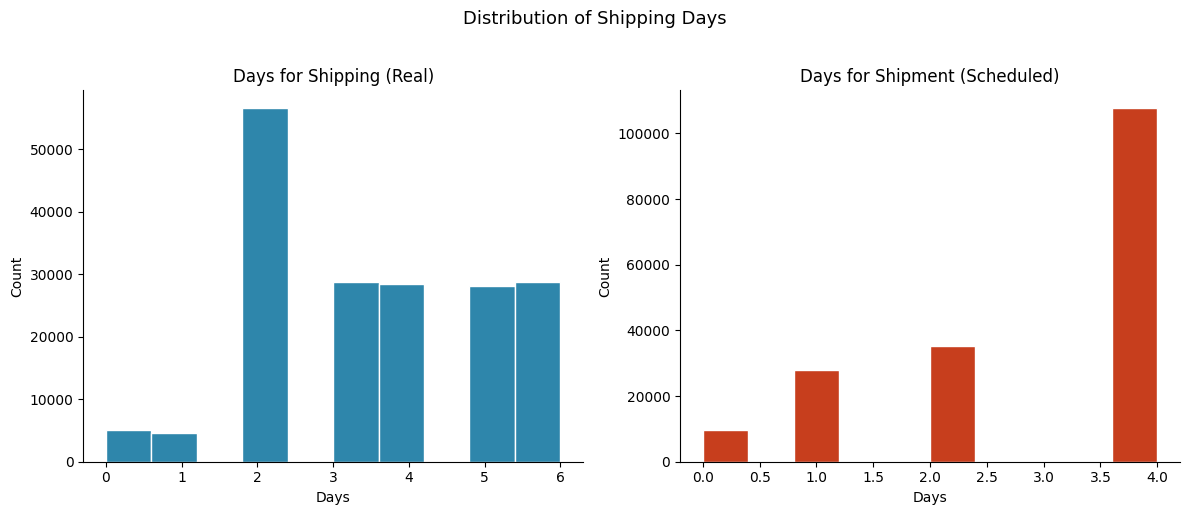

Saved: 09_shipping_days_distribution.png


In [13]:
# Shipping Day Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Days for shipping (real)'], bins=10,
             color=COLORS[0], edgecolor='white')
axes[0].set_title('Days for Shipping (Real)', fontsize=12)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')

axes[1].hist(df['Days for shipment (scheduled)'], bins=10,
             color=COLORS[3], edgecolor='white')
axes[1].set_title('Days for Shipment (Scheduled)', fontsize=12)
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Count')

plt.suptitle('Distribution of Shipping Days', fontsize=13, y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '09_shipping_days_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_shipping_days_distribution.png")

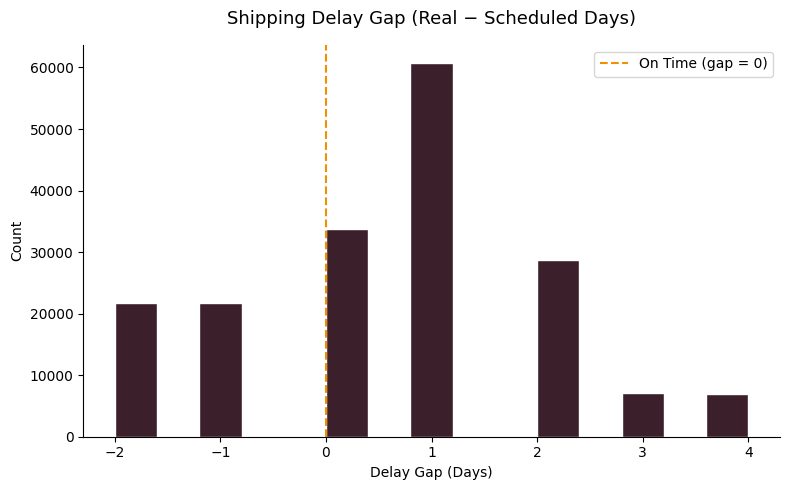

Average delay gap: 0.57 days
Orders with positive gap (late): 103,399
Orders with zero/negative gap (on time): 77,118
Saved: 10_shipping_delay_gap.png


In [14]:
# Shipping Delay Gap

df['shipping_delay_gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['shipping_delay_gap'], bins=15,
        color=COLORS[4], edgecolor='white')
ax.axvline(0, color=COLORS[2], linestyle='--', linewidth=1.5, label='On Time (gap = 0)')
ax.set_title('Shipping Delay Gap (Real − Scheduled Days)', fontsize=13, pad=15)
ax.set_xlabel('Delay Gap (Days)')
ax.set_ylabel('Count')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH + '10_shipping_delay_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average delay gap: {df['shipping_delay_gap'].mean():.2f} days")
print(f"Orders with positive gap (late): {(df['shipping_delay_gap'] > 0).sum():,}")
print(f"Orders with zero/negative gap (on time): {(df['shipping_delay_gap'] <= 0).sum():,}")
print("Saved: 10_shipping_delay_gap.png")

## 5. Numerical Feature Correlation Heatmap

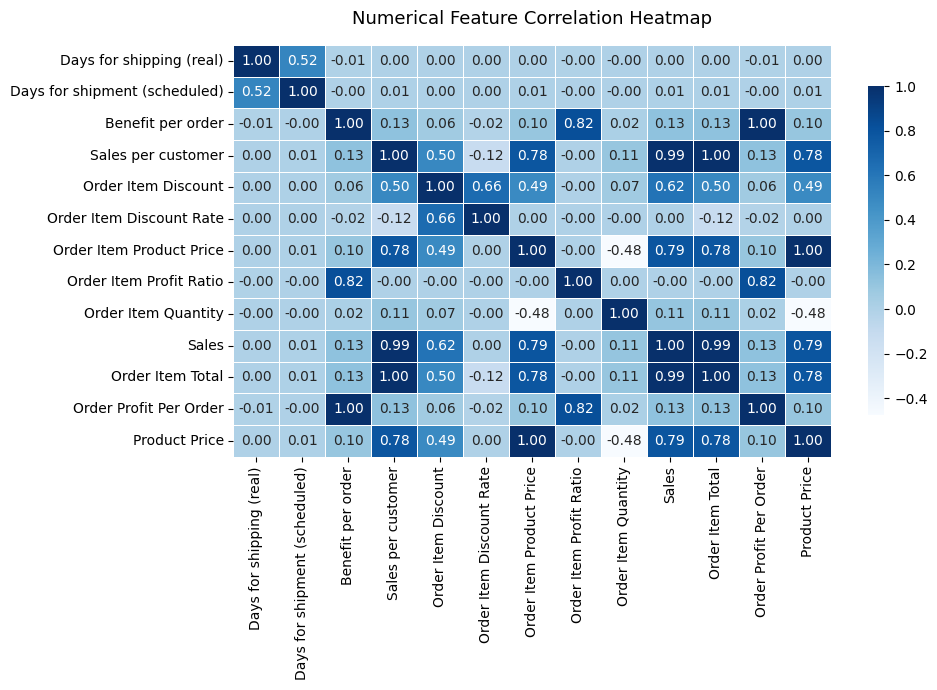

Saved: 11_correlation_heatmap.png


In [15]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'Late_delivery_risk'
                  and col != 'shipping_delay_gap']

corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Numerical Feature Correlation Heatmap', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIG_PATH + '11_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 11_correlation_heatmap.png")

## 6. EDA Summary — Key Findings

In [16]:
print("=" * 60)
print("EDA KEY FINDINGS")
print("=" * 60)

print("\n1. TARGET VARIABLE")
print(f"   Late deliveries: {df['Late_delivery_risk'].mean()*100:.2f}% of all orders")

print("\n2. SHIPPING MODE")
for mode, rate in (df.groupby('Shipping Mode')['Late_delivery_risk'].mean()*100).items():
    print(f"   {mode}: {rate:.1f}% late delivery rate")

print("\n3. MARKET")
for market, rate in (df.groupby('Market')['Late_delivery_risk'].mean()*100).sort_values(ascending=False).items():
    print(f"   {market}: {rate:.1f}% late delivery rate")

print("\n4. SHIPPING DELAY GAP")
print(f"   Average gap: {df['shipping_delay_gap'].mean():.2f} days")
print(f"   Orders shipped late: {(df['shipping_delay_gap'] > 0).sum():,}")
print(f"   Orders shipped on time: {(df['shipping_delay_gap'] <= 0).sum():,}")

EDA KEY FINDINGS

1. TARGET VARIABLE
   Late deliveries: 54.83% of all orders

2. SHIPPING MODE
   First Class: 95.3% late delivery rate
   Same Day: 45.7% late delivery rate
   Second Class: 76.6% late delivery rate
   Standard Class: 38.1% late delivery rate

3. MARKET
   Europe: 55.2% late delivery rate
   Pacific Asia: 55.0% late delivery rate
   USCA: 54.8% late delivery rate
   Africa: 54.6% late delivery rate
   LATAM: 54.4% late delivery rate

4. SHIPPING DELAY GAP
   Average gap: 0.57 days
   Orders shipped late: 103,399
   Orders shipped on time: 77,118
